<div align="center">

## 🔍 General Comparison of Clustering Algorithms

</div>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

c:\Users\talmo\anaconda3\Lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In this stage, we define a set of general exploratory questions to investigate potential patterns within the movie dataset — such as identifying groups based on commercial success, audience ratings, or structural characteristics.

For each question, we:

- Select relevant features from the dataset.
- Apply **all three clustering algorithms** (KMeans, DBSCAN, Agglomerative) on the same subset.
- Analyze and compare the clustering results across methods.

📌 **Important:**  
The questions are **not tailored to any specific algorithm**. Instead, we use them to evaluate which algorithm performs better in revealing meaningful, distinct clusters for each type of analysis.

This approach helps us assess:
- How consistently each algorithm groups the data.
- Which method produces clusters that are more interpretable.
- The overall strengths and limitations of each technique in real-world applications.


In [3]:
data = pd.read_csv('tmdb_movies_cleaned.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

##### 🧹 Removing Irrelevant or Non-Numeric Features

To reduce dimensionality and improve clustering accuracy, we removed several features that are not suitable for distance-based analysis:

- `id`, `title`: Identifiers or free text with no numerical meaning.
- `release_date`: Replaced with `release_year`, which is easier to compare.
- `top10_prod_comps`, `main_production_country`, `main_genre`, `lang_group`, `Season`: Text-based categorical fields that would require encoding and may distort distances.
- `changed_title`, `missingness_score`: Metadata or technical fields that do not describe the movie's content.

This step ensures that the clustering process is focused on interpretable and comparable features only.

In [5]:
# Start: create a copy of the original dataset
data_clean = data.copy()

# List of columns clearly not suitable for hierarchical clustering
columns_to_drop = [
    'id',                      # Unique identifier
    'title',                   # Free-text title
    'release_date',           # Date in text format
    'top10_prod_comps',       # Text field for production companies
    'main_production_country',# Text field for main country
    'season',                 # Season label (text)
    'changed_title',          # Metadata field (not content-based)
]

# Drop the selected columns
data_clean = data_clean.drop(columns=columns_to_drop)

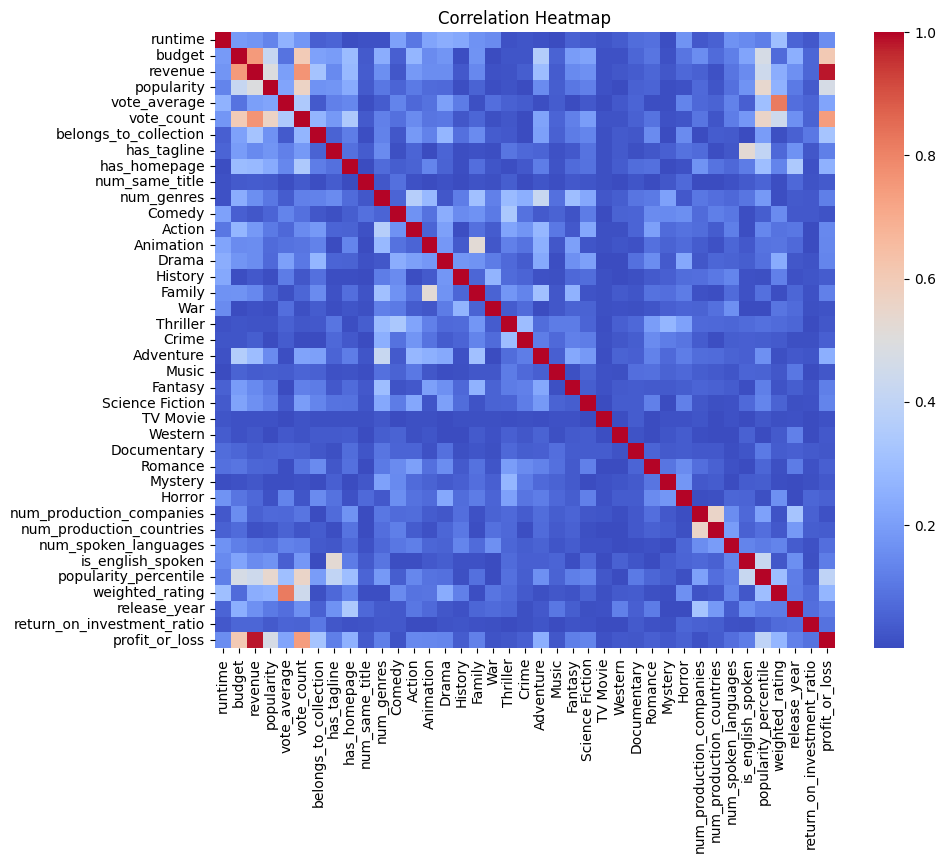

In [6]:
#אולי הסבר בגדול?
corr_matrix = data_clean.corr().abs()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [7]:
data_clean.columns

Index(['runtime', 'budget', 'revenue', 'popularity', 'vote_average',
       'vote_count', 'belongs_to_collection', 'has_tagline', 'has_homepage',
       'num_same_title', 'num_genres', 'Comedy', 'Action', 'Animation',
       'Drama', 'History', 'Family', 'War', 'Thriller', 'Crime', 'Adventure',
       'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western',
       'Documentary', 'Romance', 'Mystery', 'Horror',
       'num_production_companies', 'num_production_countries',
       'num_spoken_languages', 'is_english_spoken', 'popularity_percentile',
       'weighted_rating', 'release_year', 'return_on_investment_ratio',
       'profit_or_loss'],
      dtype='object')

## 🔄 Feature Normalization (Standardization)

Before applying clustering algorithms, we perform feature normalization using `StandardScaler`.  
This step transforms all selected features to have a mean of 0 and a standard deviation of 1.

### 🧠 Why normalize the data?
Clustering algorithms rely heavily on **distance calculations** between data points.  
When features are on different scales (e.g., budget in millions vs. vote_average from 0 to 10), the larger-scale features dominate the clustering outcome — even if they’re not more important.

Standardization ensures that **each feature contributes equally** to the clustering process, improving fairness and accuracy in distance-based methods.

### ✅ Why apply it uniformly to all algorithms?
Although some algorithms might benefit from specific preprocessing adjustments (like removing outliers for hierarchical clustering), we chose to **apply the same normalization process across all three algorithms** to maintain a fair and consistent comparison between them.

This approach allows us to:
- Compare clustering quality under the same conditions  
- Avoid introducing bias by tuning one algorithm more than the others  
- Focus on the **intrinsic behavior of each algorithm** rather than data preparation differences

In [8]:
data_clean.dtypes

runtime                         int64
budget                          int64
revenue                         int64
popularity                    float64
vote_average                  float64
vote_count                      int64
belongs_to_collection           int64
has_tagline                     int64
has_homepage                    int64
num_same_title                  int64
num_genres                      int64
Comedy                           bool
Action                           bool
Animation                        bool
Drama                            bool
History                          bool
Family                           bool
War                              bool
Thriller                         bool
Crime                            bool
Adventure                        bool
Music                            bool
Fantasy                          bool
Science Fiction                  bool
TV Movie                         bool
Western                          bool
Documentary 

In [9]:
from sklearn.preprocessing import StandardScaler

numeric_features = data_clean.select_dtypes(include=['int64', 'float64', 'bool']).columns

data_for_clustering = data_clean[numeric_features].copy()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_clustering)

data_scaled_df = pd.DataFrame(data_scaled, columns=numeric_features)


#לבדוק הפעלת לוג על חלק מפיצרים בגלל ההתפלגות

## ⚙️ Setup & Required Libraries per Algorithm

Before running the clustering algorithms, make sure to import the required libraries and preprocess the data accordingly.  
Below is a breakdown of the main imports and setup needed for each algorithm.

🔍 **Note:** At this stage, we decided **not to apply algorithm-specific adjustments** (such as removing outliers for Agglomerative Clustering or tuning `eps` specifically for DBSCAN).  
The goal is to **compare the algorithms under uniform conditions**, so we can assess their relative performance in a consistent and fair way.

This uniform setup allows us to later evaluate:
- Which algorithm naturally fits the data structure better,
- Which performs best on each question,
- And where specific tailoring might be beneficial in future iterations.

---

____
### 🔵 KMeans Clustering – Setup

In [10]:
from sklearn.cluster import KMeans

____
### 🟢 DBSCAN Clustering – Setup

In [11]:
from sklearn.cluster import DBSCAN

____
### 🟣 Agglomerative Clustering (Hierarchical) – Setup

In [12]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster


## 🧩 Question 3: Structural Patterns in Movies

**❓ Question:**  
Are there structural groupings among the movies — based on features such as runtime, release year, or number of genres — that do not necessarily relate to quality or commercial success?

**🎯 Goal:**  
To explore whether movies can be clustered according to **structural attributes** rather than content or performance. These attributes may reveal latent patterns in how movies are produced or categorized over time.

**📌 Selected Features:**  
- `runtime` — length of the movie  
- `release_year` — when the movie was released  
- `budget` — general scale of production  
- `num_genres` — how many genres were assigned to the movie  

**🔍 What we are looking for:**  
We aim to identify whether the clustering algorithms detect patterns such as:
- Movies with **short runtimes** clustering together  
- Movies released in **specific time periods** forming separate groups  
- Movies with **many genres** being distinct from single-genre films  

These patterns could hint at underlying production trends, technological changes across years, or structural similarities in content packaging.

This question is particularly useful for testing whether clustering algorithms can uncover **hidden structural trends** in the dataset that aren't explicitly tied to audience reception or box office revenue.

#המטרה היא לזהות תבניות מבניות — כלומר, תכונות טכניות של הסרטים, בלי קשר להצלחה או דירוג.


In [13]:
data_scaled_df.columns

Index(['runtime', 'budget', 'revenue', 'popularity', 'vote_average',
       'vote_count', 'belongs_to_collection', 'has_tagline', 'has_homepage',
       'num_same_title', 'num_genres', 'Comedy', 'Action', 'Animation',
       'Drama', 'History', 'Family', 'War', 'Thriller', 'Crime', 'Adventure',
       'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western',
       'Documentary', 'Romance', 'Mystery', 'Horror',
       'num_production_companies', 'num_production_countries',
       'num_spoken_languages', 'is_english_spoken', 'popularity_percentile',
       'weighted_rating', 'release_year', 'return_on_investment_ratio',
       'profit_or_loss'],
      dtype='object')

In [14]:
selected_features = [
    'runtime',
    'release_year',
    'budget',
    'num_genres',
    'belongs_to_collection',
    'num_production_companies',
    # 'num_production_countries',
    'num_spoken_languages'
]


X = data_scaled_df[selected_features].copy()
X_index = X.index  # שומרים את האינדקס המקורי


### 🧩 Feature Selection – Structural Movie Characteristics

For this clustering question, we aim to group movies based on structural or technical properties rather than success or audience response. Below are the features we selected, along with explanations of why each one is relevant:

| Feature                     | Reason for Inclusion |
|----------------------------|----------------------|
| `runtime`                  | Indicates the length of the movie – may help identify clusters of short vs. long films. |
| `release_year`             | Reflects the era of release. Movies from similar periods may share production trends or stylistic patterns. |
| `budget`                   | Budget size represents the scale of production – high-budget vs. low-budget films may form distinct groups. |
| `num_genres`               | A movie with multiple genres may differ in structure or marketing from single-genre films. |
| `belongs_to_collection`    | Identifies whether the movie is part of a series/franchise – useful for distinguishing standalone films from franchise-based productions. |
| `num_production_companies` | A high number may indicate complex or large-scale productions; low values may imply indie films. |
| `num_production_countries` | International co-productions may share characteristics distinct from single-country productions. |
| `num_spoken_languages`     | Multi-language films may target global audiences and differ structurally from single-language films. |

> These features help capture the **technical, logistical, and structural dimensions** of the movies — making them ideal for analyzing latent clusters based on production style, scope, and format.


In [15]:
X.corr()

,runtime,release_year,budget,num_genres,belongs_to_collection,num_production_companies,num_spoken_languages
runtime,1.000000,0.058511,0.187924,0.013697,-0.044512,0.029394,0.164618
release_year,0.058511,1.000000,0.247686,0.032150,0.050628,0.320476,0.036120
budget,0.187924,0.247686,1.000000,0.242635,0.207972,0.155739,0.117619
num_genres,0.013697,0.032150,0.242635,1.000000,0.127762,0.100820,0.066148
belongs_to_collection,-0.044512,0.050628,0.207972,0.127762,1.000000,0.002380,0.033874
num_production_companies,0.029394,0.320476,0.155739,0.100820,0.002380,1.000000,0.155450
num_spoken_languages,0.164618,0.036120,0.117619,0.066148,0.033874,0.155450,1.000000


Suggested cut height: 59.47


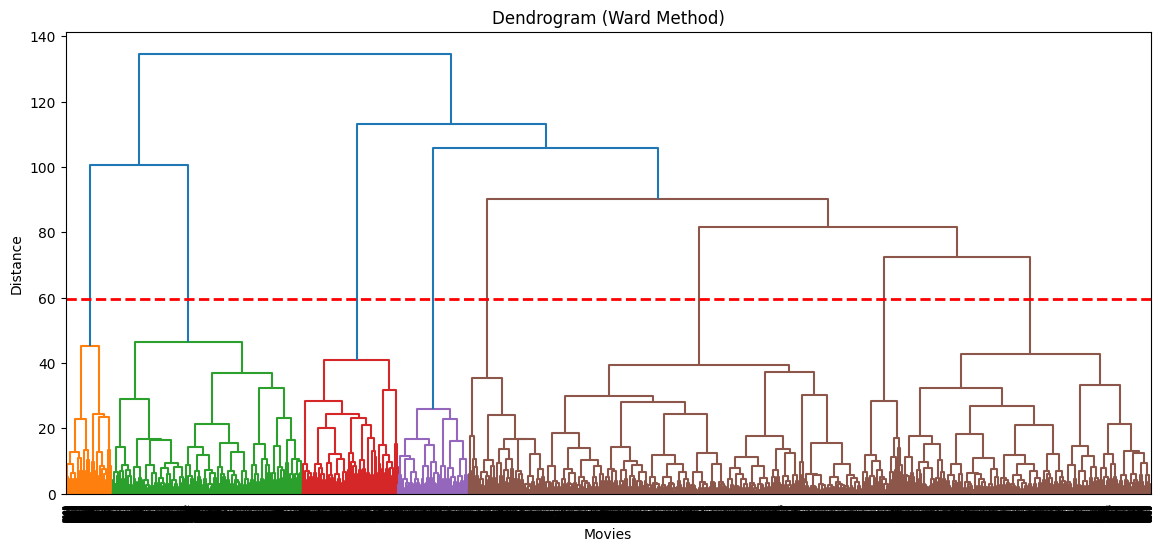

In [16]:
## 🔗 Hierarchical Clustering:

# 🔹 שלב 1: חישוב linkage (שיטת Ward)
linkage_matrix = linkage(X, method='ward')

# 🔹 שלב 2: מציאת גובה חיתוך אוטומטי
merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

print(f"Suggested cut height: {cut_height:.2f}")

# 🔹 שלב 3: דנדרוגרמה
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

In [17]:
from sklearn.decomposition import PCA

In [18]:
# 🔹 שלב 4: הרצת Clustering בפועל – נבחר למשל 3 אשכולות
k = 8
labels = fcluster(linkage_matrix, k, criterion='maxclust')

# 🔹 שלב 5: מוסיפים תוויות אשכולות לדאטה
data_scaled_df['cluster_hierarchical'] = labels.astype(str)

from sklearn.decomposition import PCA
import plotly.express as px

# 🔹 מבצעים PCA עם 3 רכיבים
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(X)

# שומרים את התוצאה ב-DataFrame
data_scaled_df['pca_1'] = pca_result_3d[:, 0]
data_scaled_df['pca_2'] = pca_result_3d[:, 1]
data_scaled_df['pca_3'] = pca_result_3d[:, 2]

# מחשבים את כמות השונות שהוסברו
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

# 🔹 גרף תלת־ממדי של הקלסטרינג לפי PCA
fig = px.scatter_3d(
    data_scaled_df,
    x='pca_1',
    y='pca_2',
    z='pca_3',
    color='cluster_hierarchical',
    title="3D PCA – Hierarchical Clustering",
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()


Total variance explained (3D): 56.71%


כן, בהחלט. כאשר ה־PCA שומר רק ~55% מהשונות ב־3 רכיבים, זה אומר ש:

או שהדאטה מפוזר על הרבה מאוד כיוונים (כלומר הרבה פיצ'רים תורמים קצת)

או שיש רעש מיותר / מידע שאינו תורם

או שהיחסים בין הפיצ'רים לא מתארים מבנים ברורים שקל לכווץ למימד נמוך

3. ✂️ הסרת פיצ'רים קורלציוניים מאוד
אם יש פיצ'רים שמאוד דומים זה לזה (למשל: budget ו־profit_loss, או num_genres ו־ז'אנרים בוליאניים), כדאי להשאיר רק אחד מהם.

4. 🧽 PCA רק אחרי ניקוי מתוחכם
לפעמים חריגים משפיעים על התוצאה — אם יש ערכים קיצוניים ב־budget, release_year, וכו’, הם עשויים להטות את כיווני PCA.
נסי להריץ PCA אחרי סינון סרטים חשודים או נורמליזציה מתקדמת יותר.

In [19]:
print(X.columns)
print("Number of features:", len(X.columns))
print("Shape of components:", pca_3d.components_.shape)


Index(['runtime', 'release_year', 'budget', 'num_genres',
       'belongs_to_collection', 'num_production_companies',
       'num_spoken_languages'],
      dtype='object')
Number of features: 7
Shape of components: (3, 7)


In [20]:
print("PCA components shape:", pca_3d.components_.shape)
print("Selected features:", X.columns.tolist())
print("Number of selected features:", len(X.columns))


PCA components shape: (3, 7)
Selected features: ['runtime', 'release_year', 'budget', 'num_genres', 'belongs_to_collection', 'num_production_companies', 'num_spoken_languages']
Number of selected features: 7


In [21]:
# נוודא שהמספרים תואמים
print("Shape of PCA components:", pca_3d.components_.shape)
print("Number of features used:", len(X.columns))

# טבלת תרומות של הפיצ'רים לרכיבי ה־PCA
pca_components_df = pd.DataFrame(
    pca_3d.components_,
    columns=X.columns,
    index=['PC1', 'PC2', 'PC3']
)

# מציגים את התרומה של כל פיצ'ר לכל רכיב (מהגבוה לנמוך עבור PC1 לדוגמה)
pca_components_df.T.sort_values(by='PC1', ascending=False)


Shape of PCA components: (3, 7)
Number of features used: 7


,PC1,PC2,PC3
budget,0.539496,0.214173,0.115135
release_year,0.442106,-0.252156,-0.479633
num_production_companies,0.432743,-0.338691,-0.401182
num_genres,0.335031,0.451967,0.100487
num_spoken_languages,0.301085,-0.263062,0.450709
runtime,0.252324,-0.329098,0.618429
belongs_to_collection,0.244243,0.627737,-0.007657


In [22]:
# # אחרי שיצרת את אובייקט ה-PCA:
# pca = PCA(n_components=2)
# pca_result = pca.fit_transform(X)

# # בודק כמה אחוז שונות נשמרו
# explained_variance = pca.explained_variance_ratio_
# total_variance = explained_variance.sum()

# print(f"Explained variance by PCA components: {explained_variance}")
# print(f"Total variance explained (2 components): {total_variance:.2%}")


#Explained variance by PCA components: [0.24803717 0.16389118]
Total variance explained (2 components): 41.19%



In [23]:
# אחרי שיצרת את אובייקט ה-PCA:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# בודק כמה אחוז שונות נשמרו
explained_variance = pca.explained_variance_ratio_
total_variance = explained_variance.sum()

print(f"Explained variance by PCA components: {explained_variance}")
print(f"Total variance explained (2 components): {total_variance:.2%}")

Explained variance by PCA components: [0.24660891 0.164352  ]
Total variance explained (2 components): 41.10%


ניסיון 
🔍 t-SNE לא שומר את אחוז השונות המוסברת, ולכן אי אפשר לחשב "כמה מידע נשמר" בצורה ישירה כמו ב־PCA.

In [24]:
# from sklearn.manifold import TSNE
# import plotly.express as px

# # 🔹 מבצעים t-SNE עם 3 רכיבים (המרה ללא פיקוח)
# tsne = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42)
# tsne_result = tsne.fit_transform(X)

# # מוסיפים את התוצאה לדאטה
# data_scaled_df['tsne_1'] = tsne_result[:, 0]
# data_scaled_df['tsne_2'] = tsne_result[:, 1]
# data_scaled_df['tsne_3'] = tsne_result[:, 2]

# # 🔹 גרף תלת־ממדי של הקלסטרינג לפי t-SNE
# fig = px.scatter_3d(
#     data_scaled_df,
#     x='tsne_1',
#     y='tsne_2',
#     z='tsne_3',
#     color='cluster_hierarchical',
#     title="3D t-SNE – Hierarchical Clustering",
#     opacity=0.7
# )

# fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
# fig.show()


In [25]:
# DBSCAN Clustering:
dbscan = DBSCAN(eps=0.7, min_samples=20)
dbscan_labels = dbscan.fit_predict(X)

data_scaled_df['cluster_dbscan'] = dbscan_labels.astype(str)

pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(X)

# 🔹 Step 4: Store PCA results in the DataFrame
data_scaled_df['pca_1'] = pca_result_3d[:, 0]
data_scaled_df['pca_2'] = pca_result_3d[:, 1]
data_scaled_df['pca_3'] = pca_result_3d[:, 2]

# 🔹 Step 5: Report explained variance
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

# 🔹 Step 6: 3D scatter plot of PCA with DBSCAN clusters
fig = px.scatter_3d(
    data_scaled_df,
    x='pca_1',
    y='pca_2',
    z='pca_3',
    color='cluster_dbscan',
    title="3D PCA – DBSCAN Clustering",
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

Total variance explained (3D): 56.71%


In [26]:

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [27]:
# import plotly.express as px


# def plot_clusters(data, feature_list, cluster_column='cluster'):
#     """
#     מציג גרף קלסטרינג תלת־ממדי או דו־ממדי לפי כמות הפיצרים.
#     מציג רק את הערכים המקוריים (עם סיומת _orig) בתוך ההובר.
#     """

#     # שימוש בדו־ממדי עם seaborn
#     if len(feature_list) == 2:
#         plt.figure(figsize=(10, 6))
#         sns.scatterplot(
#             data=data,
#             x=feature_list[0],
#             y=feature_list[1],
#             hue=cluster_column,
#             palette='Set2',
#             s=60
#         )
#         plt.title(f"2D Cluster Plot: {feature_list[0]} vs {feature_list[1]}")
#         plt.xlabel(feature_list[0])
#         plt.ylabel(feature_list[1])
#         plt.margins(x=0.1, y=0.1)
#         plt.tight_layout()
#         plt.legend(title='Cluster')
#         plt.show()

#     elif len(feature_list) == 3:
#         # עמודות מקוריות שנרצה להציג ב-hover
#         hover_cols = [col + '_orig' for col in feature_list if col + '_orig' in data.columns]

#         fig = px.scatter_3d(
#             data,
#             x=feature_list[0],
#             y=feature_list[1],
#             z=feature_list[2],
#             color=cluster_column,
#             hover_data=hover_cols,
#             opacity=0.7,
#             title=f"3D Cluster Plot: {feature_list[0]} / {feature_list[1]} / {feature_list[2]}"
#         )

#         # ניצור hovertemplate שמכיל את שם הפיצ'ר עבור כל עמודת hover
#         hovertemplate = '<br>'.join([
#             f'{col}: %{{customdata[{i}]}}' for i, col in enumerate(hover_cols)
#         ])

#         fig.update_traces(hovertemplate=hovertemplate)

#         fig.update_layout(
#             margin=dict(l=20, r=20, b=20, t=60),
#             scene=dict(
#                 xaxis=dict(title=feature_list[0], tickfont=dict(size=12)),
#                 yaxis=dict(title=feature_list[1], tickfont=dict(size=12)),
#                 zaxis=dict(title=feature_list[2], tickfont=dict(size=12)),
#                 aspectmode='manual',
#                 aspectratio=dict(x=1.3, y=1.1, z=0.9)
#             ),
#             scene_camera=dict(
#                 eye=dict(x=1.5, y=1.5, z=3)
#             )
#         )

#         fig.show()


#     else:
#         print("❌ This function only supports 2 or 3 features.")



# # plot_clusters(filtered_data, list_a)

# plot_clusters(data_cluster, list_a)




In [28]:
data_scaled_df.columns

Index(['runtime', 'budget', 'revenue', 'popularity', 'vote_average',
       'vote_count', 'belongs_to_collection', 'has_tagline', 'has_homepage',
       'num_same_title', 'num_genres', 'Comedy', 'Action', 'Animation',
       'Drama', 'History', 'Family', 'War', 'Thriller', 'Crime', 'Adventure',
       'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western',
       'Documentary', 'Romance', 'Mystery', 'Horror',
       'num_production_companies', 'num_production_countries',
       'num_spoken_languages', 'is_english_spoken', 'popularity_percentile',
       'weighted_rating', 'release_year', 'return_on_investment_ratio',
       'profit_or_loss', 'cluster_hierarchical', 'pca_1', 'pca_2', 'pca_3',
       'cluster_dbscan'],
      dtype='object')

## 🎯 Research Question: Is There a Natural Clustering of Movies Based on Critical/Audience Reception?

**Goal:**  
To examine whether movies can be grouped based on different levels of *perceived quality*, as reflected in quantitative data.

**Relevant Features:**
- `vote_average` – Average user rating
- `popularity` – General popularity metric
- `vote_count` – Number of votes

**What We Want to Discover:**  
We aim to find out if there are distinct groups among the movies, for example:
- 🎬 Movies with **high ratings** and **low viewership** – possibly cult films
- 🍿 Movies with **high popularity** but **average ratings**
- 📉 Movies with **low ratings** and **low popularity** – possibly forgotten or low-quality films

The goal is to identify whether a **natural clustering** of movies exists based on these characteristics.


selected_features = [
    'vote_average',
    'vote_count',
    'popularity',
    'popularity_percentile',
    'weighted_rating',
    'return_on_investment_ratio'
]
🔍 ניתוח לפי המתאמים:
vote_average ו־weighted_rating
מתאם גבוה מאוד של 0.986 – כמעט זהים.
✅ מומלץ להשאיר רק אחד מהם.
אם את סומכת על נוסחת weighted_rating (בדר"כ היא עדיפה כי היא לוקחת בחשבון את כמות המדרגים) – תשאירי רק אותה.

popularity ו־popularity_percentile
מתאם גבוה יחסית – 0.54.
עדיין לא מספיק גבוה כדי להסיק שזה כפילות גמורה.
⛔ לא חובה להוריד, אבל אפשר לבדוק מה נותן תוצאה טובה יותר.

return_on_investment_ratio
מתאם נמוך מאוד עם כל השאר (0.05~)
✅ זה דווקא טוב – הוא מוסיף מידע חדש ושונה (קשור להצלחה כלכלית). להשאיר.



In [29]:
selected_features = [
    'weighted_rating',
    'vote_count',
    # 'popularity',
    'popularity_percentile', #לבדוק 
    'return_on_investment_ratio'
]

X = data_scaled_df[selected_features].copy()
X_index = X.index  # שומרים את האינדקס המקורי

In [30]:
X.corr()

,weighted_rating,vote_count,popularity_percentile,return_on_investment_ratio
weighted_rating,1.000000,0.442431,0.297037,0.070693
vote_count,0.442431,1.000000,0.555324,0.052642
popularity_percentile,0.297037,0.555324,1.000000,0.042428
return_on_investment_ratio,0.070693,0.052642,0.042428,1.000000


In [ ]:
## 🔗 Hierarchical Clustering:

# 🔹 שלב 1: חישוב linkage (שיטת Ward)
linkage_matrix = linkage(X, method='ward')

# 🔹 שלב 2: מציאת גובה חיתוך אוטומטי
merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

print(f"Suggested cut height: {cut_height:.2f}")

# 🔹 שלב 3: דנדרוגרמה
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

Suggested cut height: 88.12


In [ ]:
# 🔹 שלב 4: הרצת Clustering בפועל – נבחר למשל 3 אשכולות
k = 4
labels = fcluster(linkage_matrix, k, criterion='maxclust')

# 🔹 שלב 5: מוסיפים תוויות אשכולות לדאטה
data_scaled_df['cluster_hierarchical'] = labels.astype(str)

from sklearn.decomposition import PCA
import plotly.express as px

# 🔹 מבצעים PCA עם 3 רכיבים
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(X)

# שומרים את התוצאה ב-DataFrame
data_scaled_df['pca_1'] = pca_result_3d[:, 0]
data_scaled_df['pca_2'] = pca_result_3d[:, 1]
data_scaled_df['pca_3'] = pca_result_3d[:, 2]

# מחשבים את כמות השונות שהוסברו
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

# 🔹 גרף תלת־ממדי של הקלסטרינג לפי PCA
fig = px.scatter_3d(
    data_scaled_df,
    x='pca_1',
    y='pca_2',
    z='pca_3',
    color='cluster_hierarchical',
    title="3D PCA – Hierarchical Clustering",
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()


Total variance explained (3D): 88.98%


In [ ]:
# נוודא שהמספרים תואמים
print("Shape of PCA components:", pca_3d.components_.shape)
print("Number of features used:", len(X.columns))

# טבלת תרומות של הפיצ'רים לרכיבי ה־PCA
pca_components_df = pd.DataFrame(
    pca_3d.components_,
    columns=X.columns,
    index=['PC1', 'PC2', 'PC3']
)

# מציגים את התרומה של כל פיצ'ר לכל רכיב (מהגבוה לנמוך עבור PC1 לדוגמה)
pca_components_df.T.sort_values(by='PC1', ascending=False)


Shape of PCA components: (3, 4)
Number of features used: 4


,PC1,PC2,PC3
vote_count,0.618108,-0.078512,-0.268745
popularity_percentile,0.598591,-0.097721,-0.427303
weighted_rating,0.498768,0.007276,0.860427
return_on_investment_ratio,0.104220,0.992085,-0.069668


In [ ]:
# DBSCAN Clustering:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

data_scaled_df['cluster_dbscan'] = dbscan_labels.astype(str)

pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(X)

# 🔹 Step 4: Store PCA results in the DataFrame
data_scaled_df['pca_1'] = pca_result_3d[:, 0]
data_scaled_df['pca_2'] = pca_result_3d[:, 1]
data_scaled_df['pca_3'] = pca_result_3d[:, 2]

# 🔹 Step 5: Report explained variance
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

# 🔹 Step 6: 3D scatter plot of PCA with DBSCAN clusters
fig = px.scatter_3d(
    data_scaled_df,
    x='pca_1',
    y='pca_2',
    z='pca_3',
    color='cluster_dbscan',
    title="3D PCA – DBSCAN Clustering",
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

Total variance explained (3D): 88.98%


✅ מה נרצה לראות:
🎯 קבוצה של סרטים עם דירוג גבוה אך פופולריות נמוכה → סרטים שהפכו לקאלט בקהלים קטנים

🍿 קבוצה של סרטים עם פופולריות גבוהה אך דירוג בינוני → להיטים מסחריים

🏆 קבוצה של סרטים עם גם פופולריות וגם דירוג גבוהים → הצלחה רחבה
💡 למה זו שאלה מעניינת?
היא בודקת פערים בין תפיסה איכותית לבין תפוצה, נושא מרתק בתעשיית הסרטים.


In [ ]:
!pip install --upgrade matplotlib



   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB 217.9 kB/s eta 0:00:37
   ---------------------------------------- 0.0/8.1 MB 217.9 kB/s eta 0:00:37
   ---------------------------------------- 0.1/8.1 MB 326.1 kB/s eta 0:00:25
    --------------------------------------- 0.1/8.1 MB 544.7 kB/s eta 0:00:15
    --------------------------------------- 0.2/8.1 MB 697.2 kB/s eta 0:00:12
   - -------------------------------------- 0.3/8.1 MB 983.0 kB/s eta 0:00:08
   -- ------------------------------------- 0.5/8.1 MB 1.7 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.1 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.1/8.1 MB 2.8 MB/s eta 0:00:03
   ---------- --------------

ERROR: Cannot uninstall matplotlib 3.10.1, RECORD file not found. You might be able to recover from this via: 'pip install --force-reinstall --no-deps matplotlib==3.10.1'.


In [ ]:
from mpl_toolkits.mplot3d import Axes3D


ModuleNotFoundError: No module named 'mpl_toolkits'

In [ ]:
pca = PCA(n_components=3)
scores_pca = pca.fit_transform(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(scores_pca)

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(scores_pca[:, 0], scores_pca[:, 1], scores_pca[:, 2],
                     c=labels, cmap='tab10', alpha=0.7)

ax.set_xlabel(f'PCA Component 1: {pca.explained_variance_ratio_[0] * 100:.2f}%')
ax.set_ylabel(f'PCA Component 2: {pca.explained_variance_ratio_[1] * 100:.2f}%')
ax.set_zlabel(f'PCA Component 3: {pca.explained_variance_ratio_[2] * 100:.2f}%')
ax.set_title('DBSCAN on 3D PCA-Reduced Data with Feature Loadings')
ax.legend(*scatter.legend_elements(), title="Cluster", loc='lower right')

# Offset origin
offset = 3
arrow_size = 3
feature_names = X.columns

explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

# Draw arrows from offset point
for i in range(pca.components_.shape[1]):
    ax.quiver(offset, offset, offset,
              pca.components_[0, i] * arrow_size,
              pca.components_[1, i] * arrow_size,
              pca.components_[2, i] * arrow_size,
              color='black', arrow_length_ratio=0.1, alpha=0.8)

    ax.text(offset + pca.components_[0, i] * arrow_size * 1.2,
            offset + pca.components_[1, i] * arrow_size * 1.2,
            offset + pca.components_[2, i] * arrow_size * 1.2,
            feature_names[i],
            color='black', fontsize=9, ha='center', va='center')

plt.tight_layout()
plt.show()

ValueError: Unknown projection '3d'

<Figure size 1200x1200 with 0 Axes>

## 🎯 Question 4: Are There Clusters That Reflect Dominant Genres and Content Structure?

**Goal:**  
To investigate whether movies naturally group together based on the dominance of specific genres or combinations of genres.

**Relevant Features:**  
- All binary genre features (e.g., `Comedy`, `Drama`, `Horror`, `Action`, `Fantasy`, etc.)  
- `num_genres` – total number of genres associated with the movie

**What We Want to Observe:**  
- 🎬 A cluster of movies dominated by a **single genre** (e.g., only `Horror`)
- 🎭 A cluster of movies with **multiple genre combinations** (e.g., `Action-Comedy`, `Fantasy-Drama`)

The goal is to understand whether genre structure leads to natural separation in the data.



In [ ]:
# 🎯 Selected features for clustering by genre structure
selected_features = [
    'num_genres',       # number of genres per movie
    'Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
    'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
    'TV Movie', 'Thriller', 'War', 'Western'
]

# Create the feature matrix for clustering
X = data_scaled_df[selected_features].copy()
X_index = X.index  # preserve original index


❗ למה זה עשוי להיות בעייתי?
סקלה שווה לכולם – כל ז'אנר הוא רק 0 או 1, ואין הבדל בין "דרמה חזקה" ל"הוזכרה מילה על דרמה".

קירבה מלאכותית – סרטים עם הרבה ז'אנרים משותפים יקבלו מרחק קטן, גם אם בפועל הם מאוד שונים בתוכן (למשל Action+Comedy מול Comedy+Romance).

PCA מניח רציפות – ופה הפיצ'רים דיסקרטיים (0/1), מה שלא תמיד מייצג את הדאטה טוב במרחב ריאלי.

✅ מתי זה כן בסדר?
למרות זאת – במקרים כמו שלך:

מדובר בז'אנרים מוגדרים היטב עם משמעות חזקה (Horror ≠ Comedy).

המטרה שלך היא לזהות דומיננטיות או שילובים – ולכן ייצוג בינארי פשוט דווקא הגיוני.

הוספת num_genres עוזרת להבחין בין סרטים עם ז'אנר יחיד לעומת מרובים.

🔄 פתרונות אפשריים לשיפור:
אם תראי שהאשכולות לא מובהקים מספיק, אפשר לשקול:

שימוש ב־Jaccard distance במקום מרחק אוקלידי — מותאם למערכים בינאריים.

שימוש ב־UMAP במקום t-SNE או PCA — מתמודד טוב עם בינאריים.

יצירת פיצ'ר טקסטואלי מאוחד (למשל "Action_Comedy") והמרתו ל־TF-IDF או CountVectorizer.


ליצור פיצ'ר כמו: main_genre (הז'אנר הראשון/הדומיננטי)

בהחלט כן — רעיון מצוין!
הפחתת כמות הפיצ'רים יכולה:

להוריד רעש (noise)

להבליט מבנה ברור יותר באשכולות

לשפר את אחוז השונות המוסברת ב־PCA

ולהתאים טוב יותר ל־KMeans, Hierarchical ו־t-SNE

🎯 אז מה כדאי להסיר?
1. 🔁 ז’אנרים נדירים מאוד
אם יש ז'אנרים שמופיעים במעט מאוד סרטים (למשל TV Movie, Western, Music), הם כמעט תמיד יהיו 0, ולא יועילו לחלוקה — רק יבלבלו את האלגוריתמים.

2. 📉 ז’אנרים שמופיעים בכל הסרטים
אם יש ז’אנר שמופיע כמעט תמיד (כמו Drama בד"כ), הוא לא מבחין בין קבוצות → אפשר להוריד.

3. ⚠ ז’אנרים מאוד חופפים (למשל Fantasy ו־Adventure)
אם תראי מתאם גבוה ביניהם, אפשר לבחור רק אחד.

In [ ]:
# 1. מחשבים שכיחות של כל ז'אנר
genre_cols = [
    'Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
    'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
    'TV Movie', 'Thriller', 'War', 'Western'
]

# סופרים כמה סרטים שייכים לכל ז'אנר
genre_counts = data[genre_cols].sum().sort_values()

# מדפיסים כדי לראות מה נדיר
print(genre_counts)


TV Movie             17
Documentary         132
Western             187
War                 376
Music               418
History             519
Animation           522
Mystery             785
Fantasy             922
Science Fiction     984
Family             1001
Horror             1108
Crime              1569
Adventure          1683
Romance            2022
Action             2308
Thriller           2393
Comedy             3682
Drama              4832
dtype: int64


✅ המלצה: להשאיר רק ז’אנרים שמופיעים בלפחות ~10% מהסרטים
כלומר ≈ 500 סרטים ומעלה


In [ ]:
# 🎯 Selected features for clustering by genre structure
selected_features = [
    'num_genres',       # number of genres per movie
    'History', 'Animation', 'Mystery', 'Fantasy', 'Science Fiction',
    'Family', 'Horror', 'Crime', 'Adventure', 'Romance',
    'Action', 'Thriller', 'Comedy', 'Drama'
]

# Create the feature matrix for clustering
X = data_scaled_df[selected_features].copy()
X_index = X.index  # preserve original index


In [ ]:
X.corr()

,num_genres,History,Animation,Mystery,Fantasy,Science Fiction,Family,Horror,Crime,Adventure,Romance,Action,Thriller,Comedy,Drama
num_genres,1.000000,0.117217,0.284874,0.207995,0.300157,0.230123,0.305216,0.027867,0.246393,0.423693,0.108801,0.370675,0.288947,0.055099,0.026833
History,0.117217,1.000000,-0.032882,-0.043483,-0.065591,-0.074661,-0.061903,-0.075831,-0.056820,0.013551,-0.033065,-0.004659,-0.071682,-0.150707,0.179070
Animation,0.284874,-0.032882,1.000000,-0.052121,0.204649,0.021733,0.522236,-0.073237,-0.090644,0.253383,-0.085186,-0.056649,-0.123926,0.086718,-0.179834
Mystery,0.207995,-0.043483,-0.052121,1.000000,-0.033067,-0.000760,-0.079258,0.176122,0.115848,-0.070347,-0.094941,-0.072455,0.270632,-0.147009,-0.032894
Fantasy,0.300157,-0.065591,0.204649,-0.033067,1.000000,0.041620,0.260720,0.041163,-0.123008,0.230298,-0.032135,0.030544,-0.111647,0.019321,-0.164067
Science Fiction,0.230123,-0.074661,0.021733,-0.000760,0.041620,1.000000,-0.018986,0.124634,-0.115576,0.185542,-0.124577,0.225574,0.056254,-0.111570,-0.205901
Family,0.305216,-0.061903,0.522236,-0.079258,0.260720,-0.018986,1.000000,-0.111980,-0.130907,0.307234,-0.086646,-0.084791,-0.178754,0.165851,-0.171088
Horror,0.027867,-0.075831,-0.073237,0.176122,0.041163,0.124634,-0.111980,1.000000,-0.097009,-0.115351,-0.150922,-0.089262,0.207505,-0.160047,-0.230034
Crime,0.246393,-0.056820,-0.090644,0.115848,-0.123008,-0.115576,-0.130907,-0.097009,1.000000,-0.116447,-0.149903,0.174538,0.295989,-0.088767,0.037667
Adventure,0.423693,0.013551,0.253383,-0.070347,0.230298,0.185542,0.307234,-0.115351,-0.116447,1.000000,-0.128516,0.276103,-0.076926,-0.033649,-0.231186


Suggested cut height: 164.92


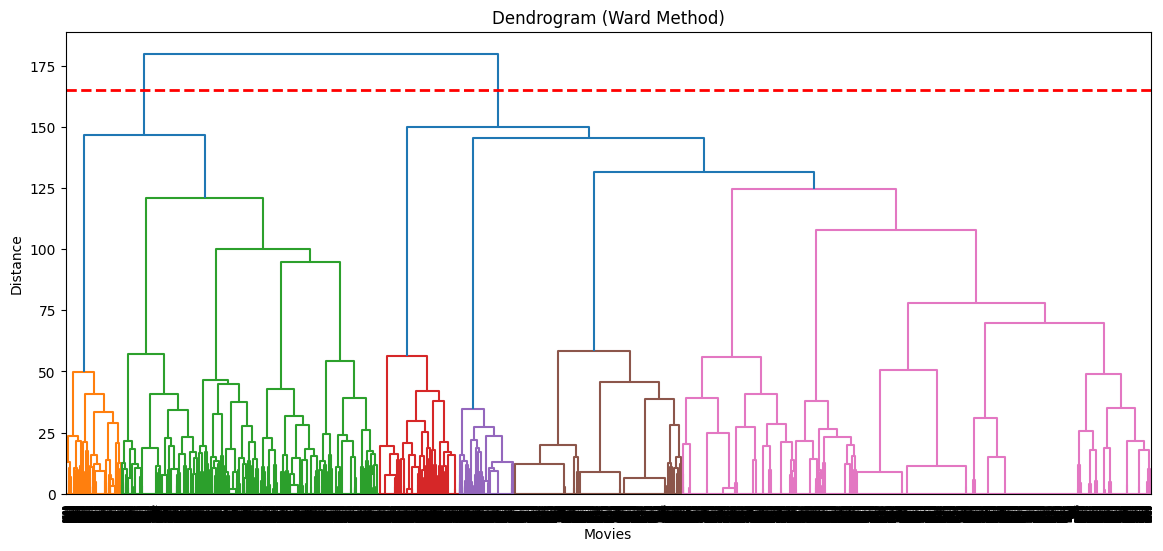

In [ ]:
## 🔗 Hierarchical Clustering:

# 🔹 שלב 1: חישוב linkage (שיטת Ward)
linkage_matrix = linkage(X, method='ward')

# 🔹 שלב 2: מציאת גובה חיתוך אוטומטי
merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

print(f"Suggested cut height: {cut_height:.2f}")

# 🔹 שלב 3: דנדרוגרמה
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

In [ ]:
# 🔹 שלב 4: הרצת Clustering בפועל – נבחר למשל 3 אשכולות
k = 6
labels = fcluster(linkage_matrix, k, criterion='maxclust')

# 🔹 שלב 5: מוסיפים תוויות אשכולות לדאטה
data_scaled_df['cluster_hierarchical'] = labels.astype(str)

from sklearn.decomposition import PCA
import plotly.express as px

# 🔹 מבצעים PCA עם 3 רכיבים
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(X)

# שומרים את התוצאה ב-DataFrame
data_scaled_df['pca_1'] = pca_result_3d[:, 0]
data_scaled_df['pca_2'] = pca_result_3d[:, 1]
data_scaled_df['pca_3'] = pca_result_3d[:, 2]

# מחשבים את כמות השונות שהוסברו
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

# 🔹 גרף תלת־ממדי של הקלסטרינג לפי PCA
fig = px.scatter_3d(
    data_scaled_df,
    x='pca_1',
    y='pca_2',
    z='pca_3',
    color='cluster_hierarchical',
    title="3D PCA – Hierarchical Clustering",
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()


NameError: name 'fcluster' is not defined

🔚 סיכום קצר:
41.24% זה סביר במצב של פיצ’רים בינאריים.

In [ ]:
# נוודא שהמספרים תואמים
print("Shape of PCA components:", pca_3d.components_.shape)
print("Number of features used:", len(X.columns))

# טבלת תרומות של הפיצ'רים לרכיבי ה־PCA
pca_components_df = pd.DataFrame(
    pca_3d.components_,
    columns=X.columns,
    index=['PC1', 'PC2', 'PC3']
)

# מציגים את התרומה של כל פיצ'ר לכל רכיב (מהגבוה לנמוך עבור PC1 לדוגמה)
pca_components_df.T.sort_values(by='PC1', ascending=False)


❓ שאלה 5: האם ניתן לזהות קבוצות סרטים לפי מאפייני הפצה ותעשייה?
🎯 מטרה:
לבדוק האם קיימות קבוצות שונות של סרטים על בסיס מאפייני הפצה, כמו מספר שפות, מספר חברות הפקה, שייכות לאוסף, ותקציב – שמעידים על סגנון ההפקה והיעד השיווקי.

🧩 פיצ'רים רלוונטיים:
budget

num_production_companies

num_spoken_languages

belongs_to_collection

num_production_countries (אם רלוונטי)

אולי גם release_year כדי לבדוק אם זה השתנה לאורך זמן

✅ מה נרצה לראות:
קבוצה של סרטים עם הרבה חברות הפקה ושפות → פרויקטים בינלאומיים

קבוצה של סרטים עם הפצה צרה (שפה אחת, ללא אוסף) → אינדי או הפצה מקומית

קבוצה של סרטים שהם חלק מאוסף (franchise) → סרטי המשך, יקום קולנועי

כל מה שלמטה לא לגעת

In [ ]:
# # 🔹 שלב 10: ניתוח הקלאסטרים
# cluster_medians = data.groupby('cluster')[['budget', 'revenue', 'vote_average', 'vote_count', 'popularity', 'runtime', 'return_on_investment_ratio']].median()
# display(cluster_medians)
# #פרשנות וניתוח
# #לההראות שעשיתי ממוצע ואז העברתי לחציון ולמה

,budget,revenue,vote_average,vote_count,popularity,runtime,return_on_investment_ratio
cluster,,,,,,,
1,165000000.0,811354856.0,7.236,13705.5,17.11885,129.0,3.986763
2,31000000.0,61601280.0,6.600,1739.0,5.08700,113.0,0.901337
3,7000000.0,9810553.5,6.300,314.0,2.61130,102.0,0.651296


In [ ]:
# # 🔹 שלב 11: הצגת דוגמאות לכל קלאסטר (כולל שם הסרט)
# columns_to_show = ['title', 'budget', 'revenue', 'vote_average', 'popularity', 'return_on_investment_ratio']
# for c in sorted(data['cluster'].unique()):
#     print(f"\n=== Cluster {c} ===")
#     display(data[data['cluster'] == c][columns_to_show].sample(5, random_state=42))



=== Cluster 1 ===


,title,budget,revenue,vote_average,popularity,return_on_investment_ratio
351,E.T. the Extra-Terrestrial,10500000,792965500,7.514,16.1838,74.520524
2013,Kung Fu Panda,130000000,632091832,7.297,19.1998,3.862245
8977,Mission: Impossible - Fallout,178000000,791658205,7.430,13.7575,3.447518
7492,X-Men: Days of Future Past,250000000,747862775,7.527,9.7118,1.991451
8841,Transformers: The Last Knight,217000000,605425157,6.053,73.7017,1.789978



=== Cluster 2 ===


,title,budget,revenue,vote_average,popularity,return_on_investment_ratio
6602,The Last Train,2500000,481199,6.300,0.4096,-0.807520
284,The Green Mile,60000000,286801374,8.504,37.1617,3.780023
1883,Flightplan,55000000,223387299,6.456,9.2942,3.061587
1781,Just Like Heaven,58000000,102900000,6.963,7.9146,0.774138
7095,Shadow Dancer,6300000,1777709,5.935,2.6843,-0.717824



=== Cluster 3 ===


,title,budget,revenue,vote_average,popularity,return_on_investment_ratio
8807,Julieta,1490000,22468044,7.000,3.0189,14.079224
815,Phone Booth,13000000,97837138,6.848,3.1575,6.525934
8091,Moshi Monsters: The Movie,1849089,2900000,6.300,0.8116,0.568340
6691,Snowtown,2000000,1349387,6.300,2.2054,-0.325306
3147,Fright Night,9000000,24922237,7.036,3.4984,1.769137


להוסיף מסקנות וכאלה 

In [ ]:
# # 🔹 שלב 12: חישוב מדדים להערכת הקלאסטרים
# from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [ ]:
# data_cluster['cluster'].value_counts()


KeyError: 'cluster'

In [ ]:
# print("Silhouette Score:", silhouette_score(data_scaled, data['cluster']))
# print("Calinski-Harabasz Index:", calinski_harabasz_score(data_scaled, data['cluster']))
# print("Davies-Bouldin Index:", davies_bouldin_score(data_scaled, data['cluster']))

# # 🔹 שלב 13: ניסוי וטעייה – נסי שוב עם k שונה (למשל 3 או 5)
# # חזרי על שלבים 8–12 עם ערכים שונים ובחרי את הקלאסטרינג הכי ברור ופרשני

# # 🔹 שלב 14: סיכום מילולי
# # הסבירי את ההיגיון של כל קלאסטר לפי המאפיינים המרכזיים
# # לדוגמה: קלאסטר 1 = סרטים גדולים עם ROI גבוה, קלאסטר 3 = סרטים קטנים שנכשלו

 שלב 9: כתיבת סיכום תובנות
 כתבי פסקה אחת על מה למדת מכל קלאסטר (מי הקבוצות, במה הן שונות)

 קשרי את הקלאסטרים לדפוסים קולנועיים מוכרים (למשל: "סרטים נישתיים מצליחים" או "סרטים עתירי תקציב עם דירוג נמוך")

✅ מה אפשר לעשות הלאה:
לחשב את הממוצעים של הפיצ'רים בכל קלאסטר כדי לפרש מה מייחד כל קבוצה.

לבדוק האם הקבוצה בצד ימין מייצגת בלוקבסטרים/סרטים יוקרתיים.

לשקול לבצע PCA על קבוצה נפרדת של פיצ'רים (כמו רק פופולריות והכנסות) כדי לראות אם המבנה משתפר.